In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.shape

(614, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [7]:
df.drop(columns ="Loan_ID",inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [10]:
df.Gender.fillna("Unknown",inplace=True)
df.Married.fillna(df.Married.mode()[0],inplace=True)
df.Dependents.fillna(df.Dependents.mode()[0],inplace=True)
df.Self_Employed.fillna("NA",inplace=True)
df.Loan_Amount_Term.fillna(df.Loan_Amount_Term.mode()[0],inplace=True)
df.Credit_History.fillna(df.Credit_History.mode()[0],inplace=True)

In [11]:
df.LoanAmount.mean()

np.float64(146.41216216216216)

In [12]:
df.LoanAmount.median()

128.0

In [13]:
df.LoanAmount.fillna(df.LoanAmount.median(),inplace=True)
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
category=df.select_dtypes(include="object")
category

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,Urban,Y
1,Male,Yes,1,Graduate,No,Rural,N
2,Male,Yes,0,Graduate,Yes,Urban,Y
3,Male,Yes,0,Not Graduate,No,Urban,Y
4,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,Rural,Y
610,Male,Yes,3+,Graduate,No,Rural,Y
611,Male,Yes,1,Graduate,No,Urban,Y
612,Male,Yes,2,Graduate,No,Urban,Y


In [15]:
for i in category:
    print(i)
    print("---------------")
    print(df[i].value_counts())
    print("="*100)
    

Gender
---------------
Gender
Male       489
Female     112
Unknown     13
Name: count, dtype: int64
Married
---------------
Married
Yes    401
No     213
Name: count, dtype: int64
Dependents
---------------
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64
Education
---------------
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64
Self_Employed
---------------
Self_Employed
No     500
Yes     82
NA      32
Name: count, dtype: int64
Property_Area
---------------
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64
Loan_Status
---------------
Loan_Status
Y    422
N    192
Name: count, dtype: int64


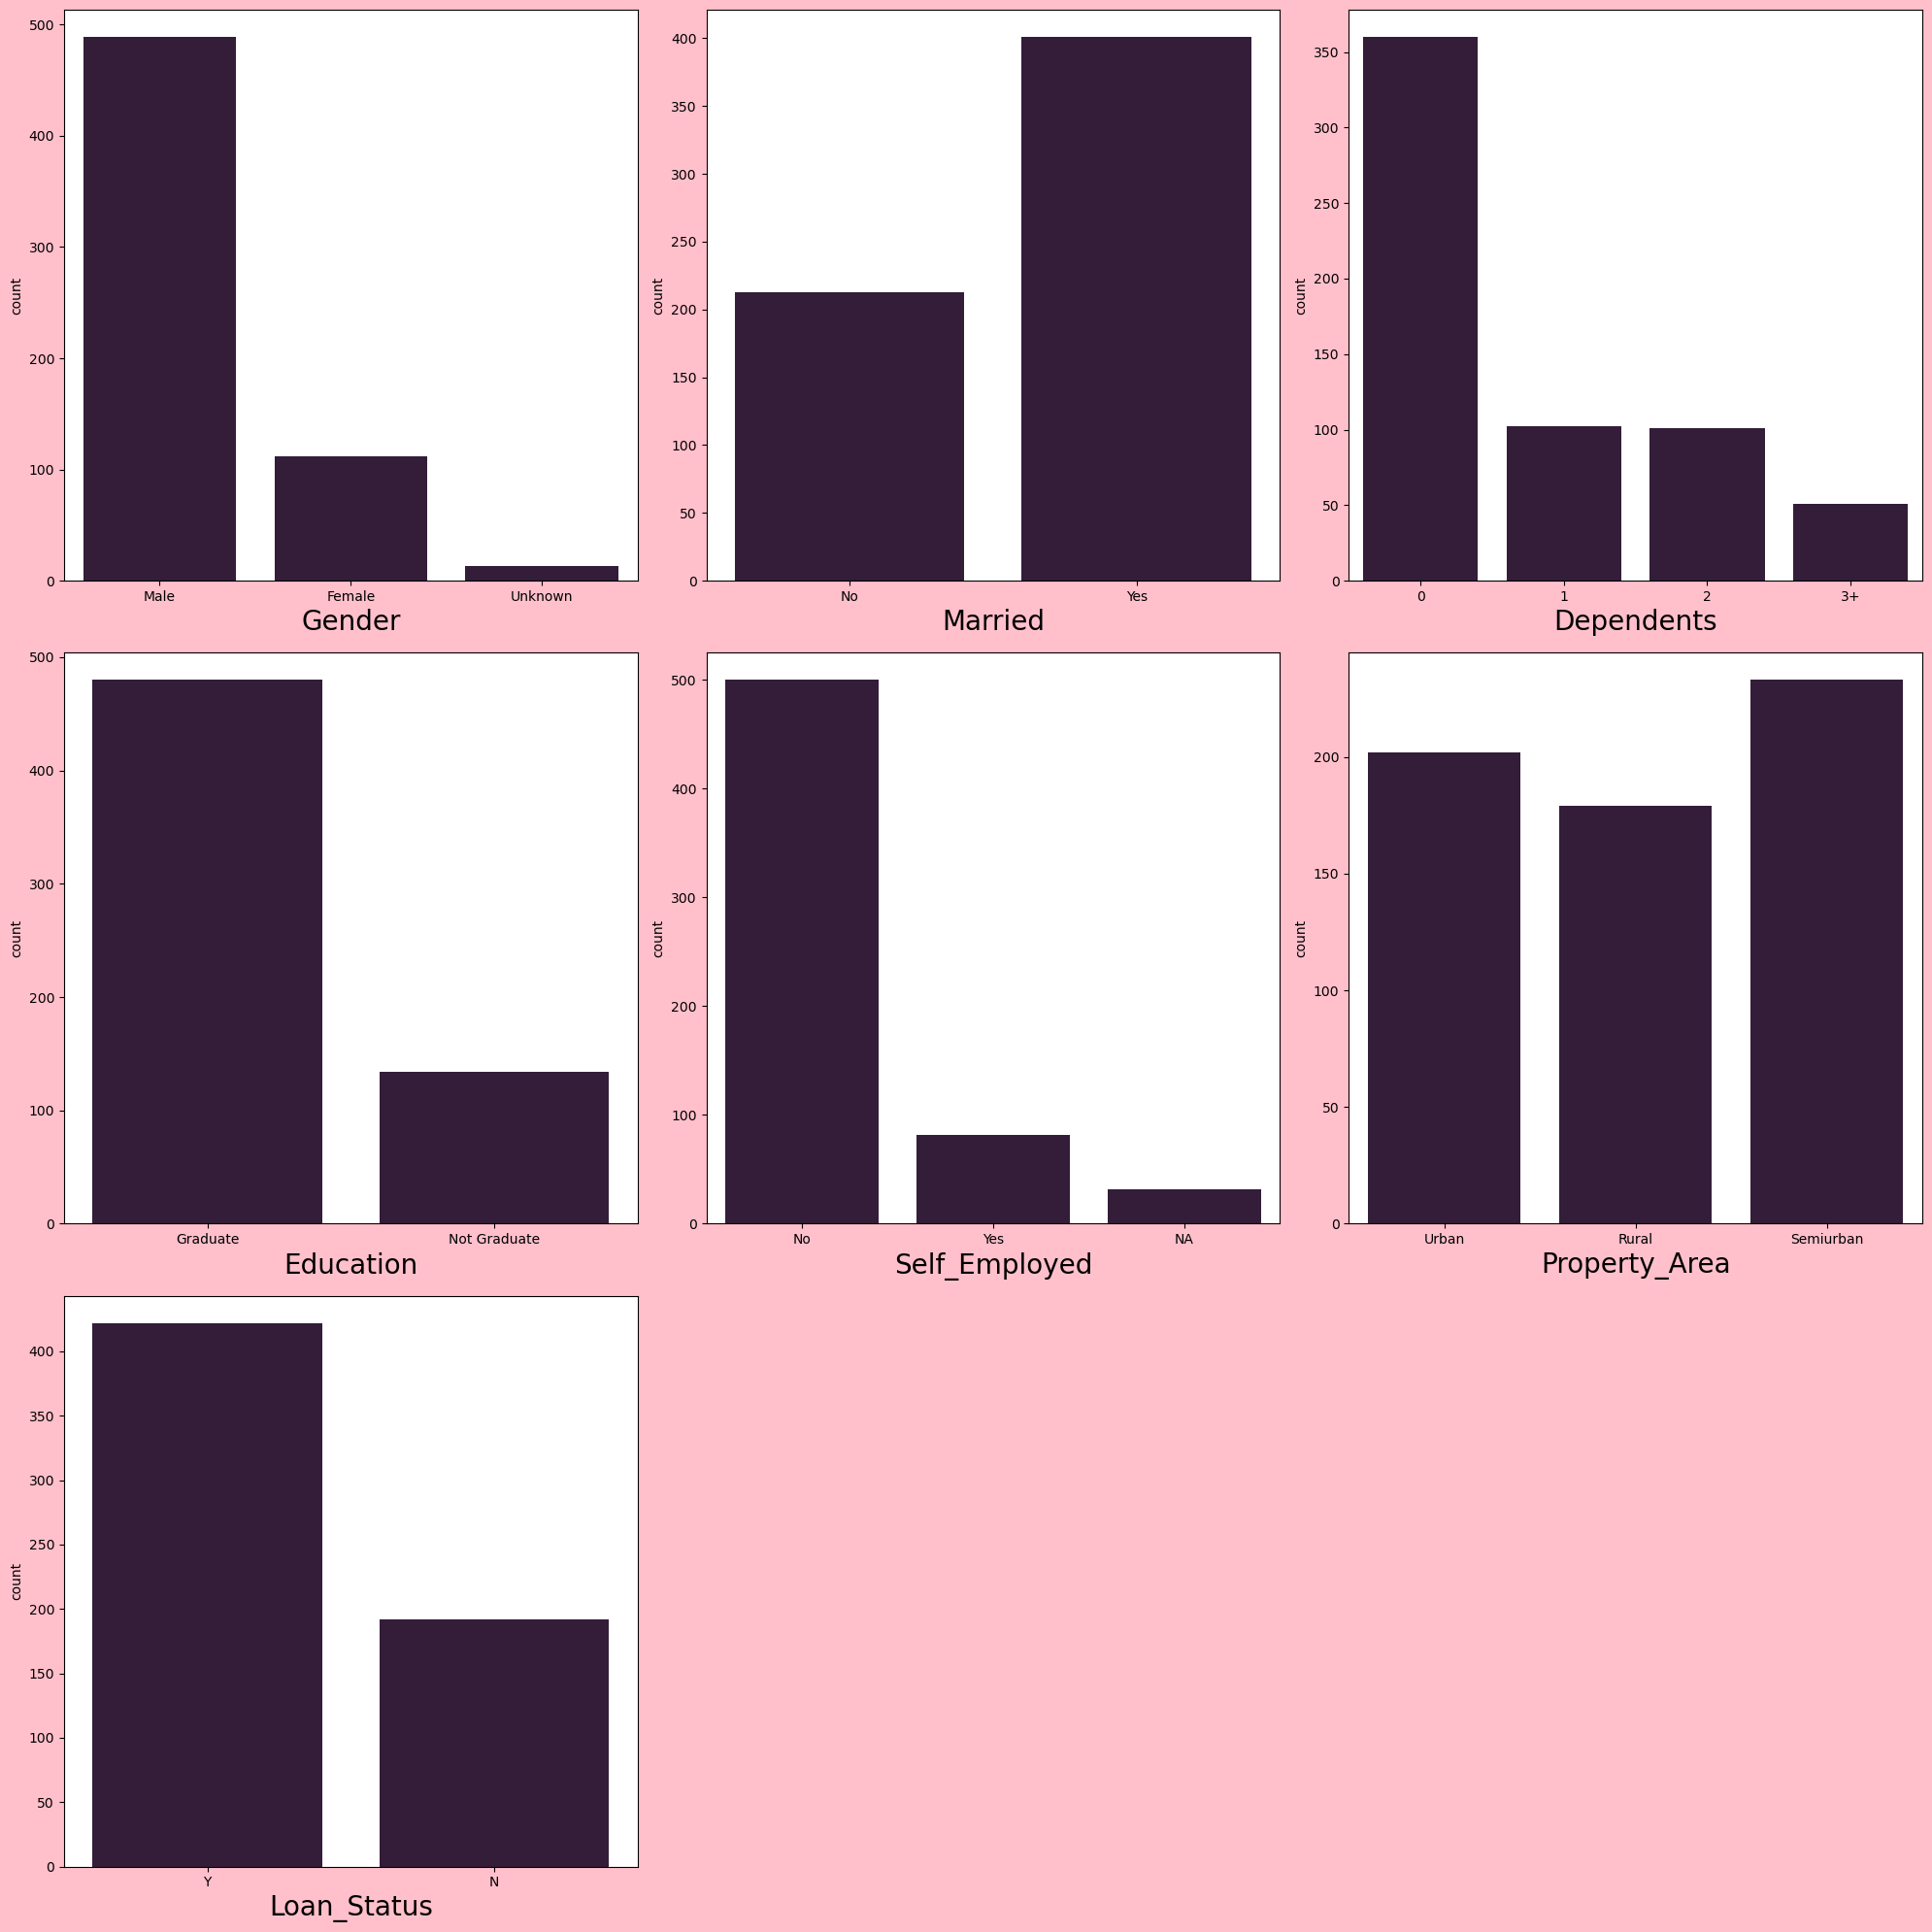

In [16]:
sns.set_palette('rocket')
plt.figure(figsize=(20,20),facecolor='pink')
plotnumber=1
for i in category:
    if plotnumber<=7:
        ax=plt.subplot(3,3,plotnumber)
        sns.countplot(x=df[i])
        plt.xlabel(i,fontsize=20)
    plotnumber+=1
plt.tight_layout()
plt.show()

<Axes: ylabel='LoanAmount'>

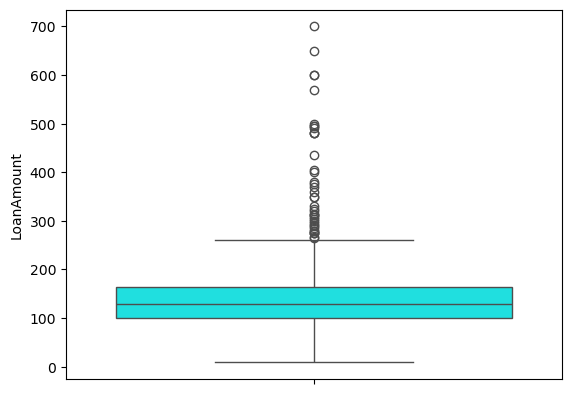

In [17]:
sns.boxplot(y="LoanAmount",data=df,color="cyan")

<Axes: xlabel='LoanAmount', ylabel='Density'>

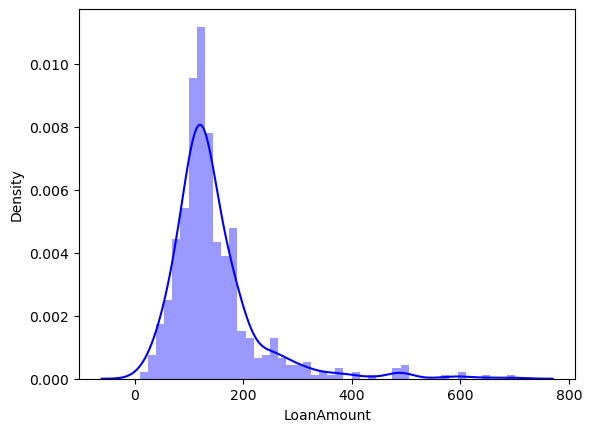

In [18]:
sns.distplot(df.LoanAmount,color='b')

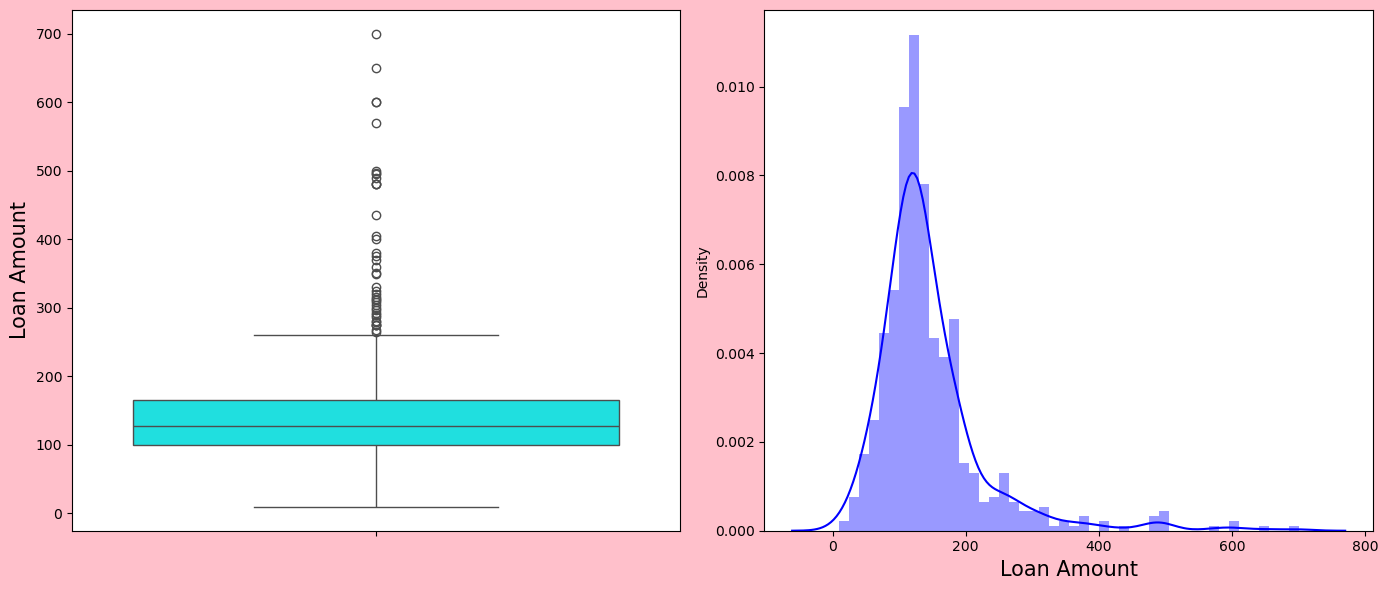

In [19]:
plt.figure(figsize=(14,6),facecolor='pink')
plt.subplot(1,2,1)
sns.boxplot(y="LoanAmount",data=df,color="cyan")
plt.ylabel("Loan Amount",fontsize=15)
plt.subplot(1,2,2)
sns.distplot(df['LoanAmount'],color='b')
plt.xlabel("Loan Amount",fontsize=15)
plt.tight_layout()
plt.show()

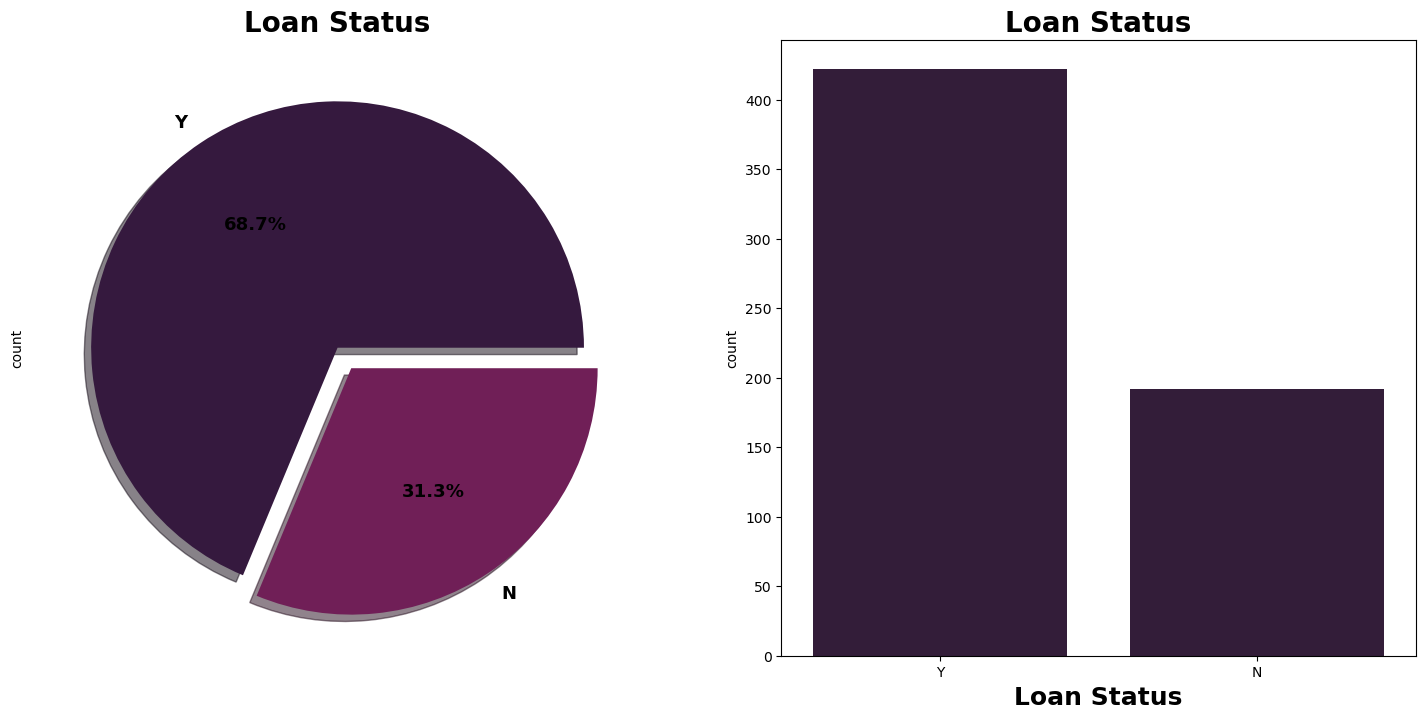

In [24]:
sns.set_palette("rocket")
f,ax=plt.subplots(1,2,figsize=(18,8))
df.Loan_Status.value_counts().plot.pie(explode=[0,0.1],
                                       autopct='%2.1f%%',
                                      textprops={'fontweight':'bold','fontsize':13},
                                      ax=ax[0],
                                      shadow=True)
ax[0].set_title('Loan Status',
                fontsize=20,
                fontweight='bold')
sns.countplot(x='Loan_Status',
             data=df,
             ax=ax[1])
ax[1].set_title('Loan Status',
                fontsize=20,
                fontweight='bold')
ax[1].set_xlabel('Loan Status',
                fontsize=18,
                fontweight='bold')
plt.show()

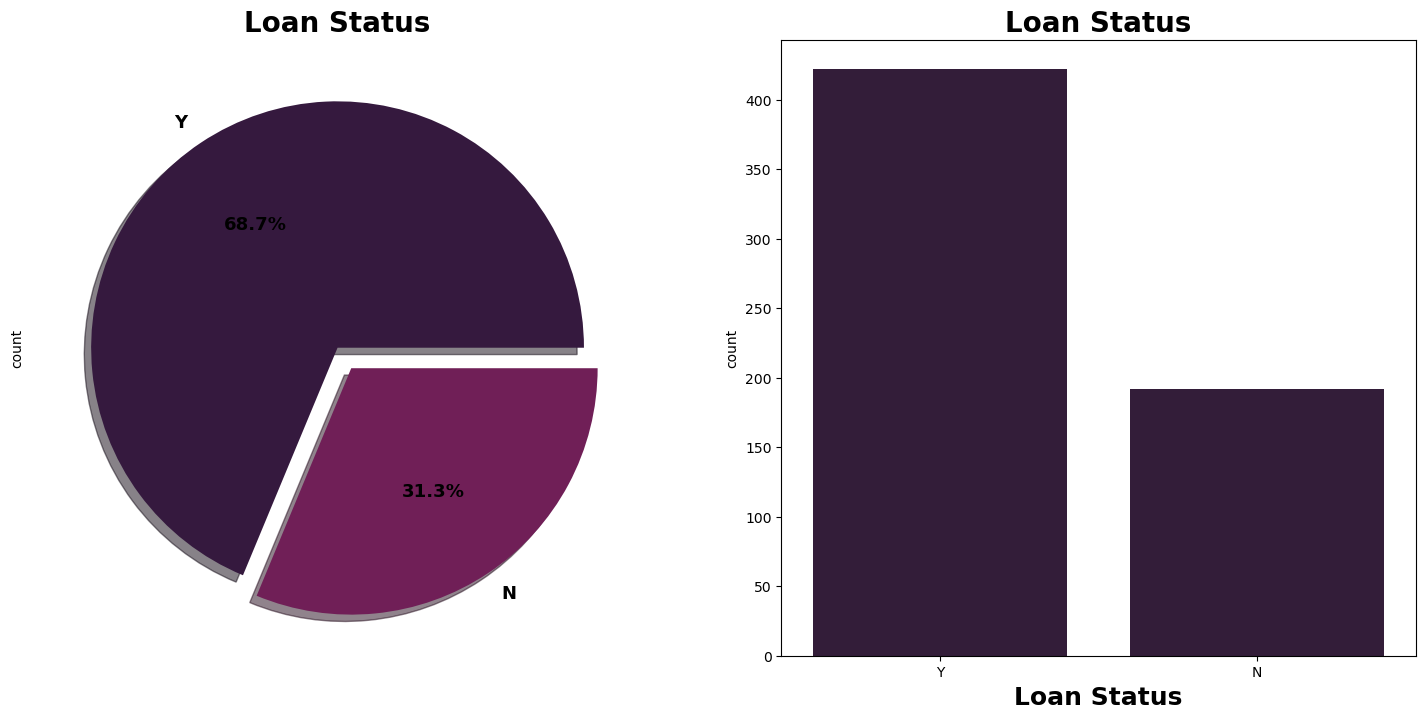

In [29]:
sns.set_palette("rocket")
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)

df.Loan_Status.value_counts().plot.pie(explode=[0,0.1],
                                       autopct='%2.1f%%',
                                      textprops={'fontweight':'bold','fontsize':13},
                                      shadow=True)
plt.title('Loan Status',
                fontsize=20,
                fontweight='bold')
plt.subplot(1,2,2)

sns.countplot(x='Loan_Status',
             data=df)
plt.title('Loan Status',
                fontsize=20,
                fontweight='bold')
plt.xlabel('Loan Status',
                fontsize=18,
                fontweight='bold')
plt.show()

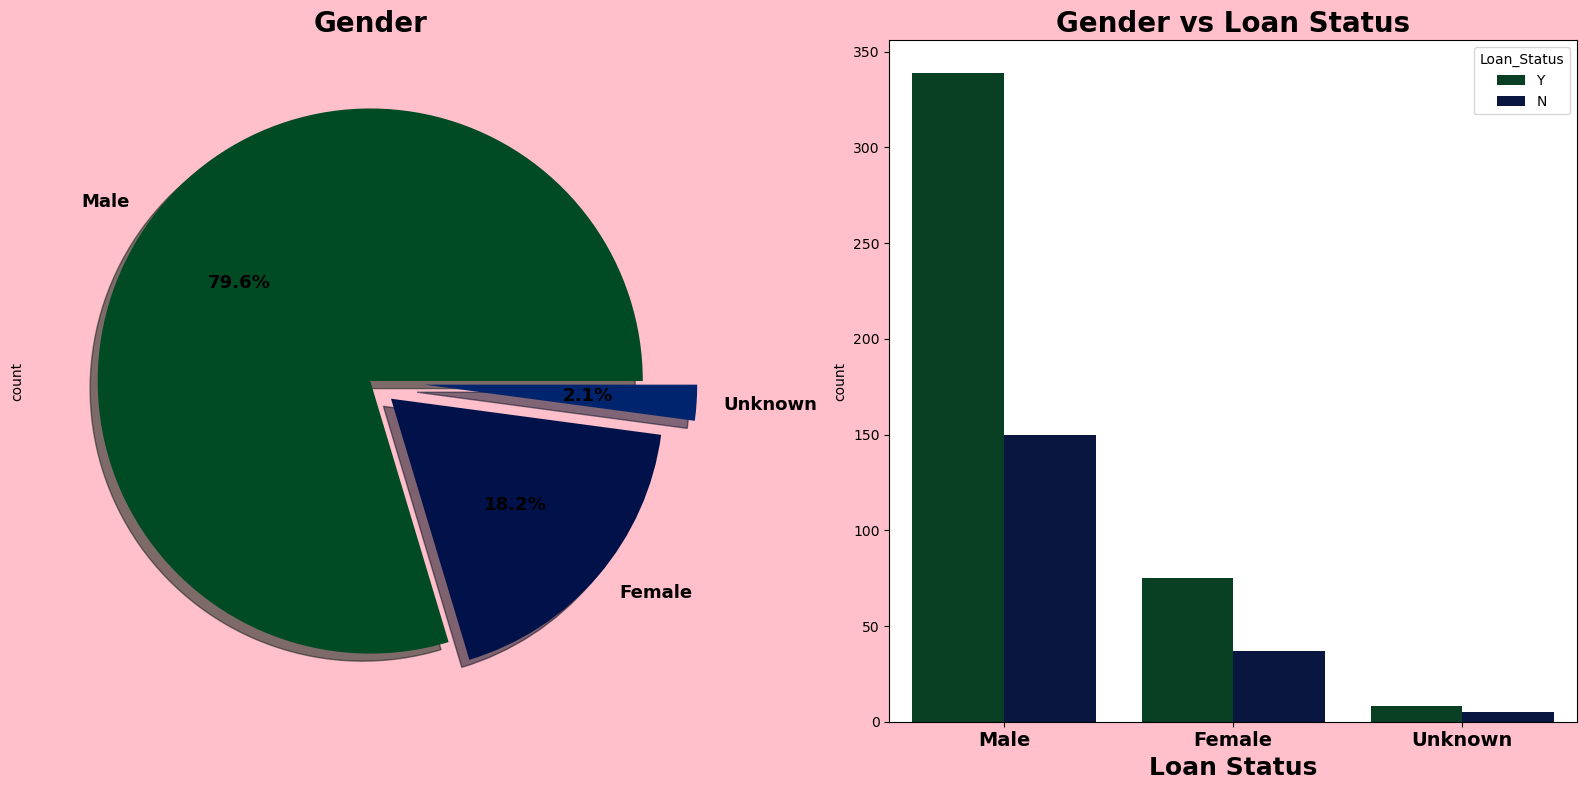

In [48]:
sns.set_palette("ocean")
f,ax=plt.subplots(1,2,figsize=(16,8),facecolor='pink')
df.Gender.value_counts().plot.pie(explode=[0,0.1,0.2],
                                       autopct='%2.1f%%',
                                      textprops={'fontweight':'bold',
                                                 'fontsize':13},
                                      ax=ax[0],
                                      shadow=True)
ax[0].set_title('Gender',
                fontsize=20,
                fontweight='bold')
sns.countplot(x='Gender',
              hue="Loan_Status",
             data=df,
             ax=ax[1])
ax[1].set_title('Gender vs Loan Status',
                fontsize=20,
                fontweight='bold')
ax[1].set_xlabel('Loan Status',
                fontsize=18,
                fontweight='bold')
plt.xticks(fontsize=14,
          fontweight='bold')
plt.tight_layout()
plt.show()

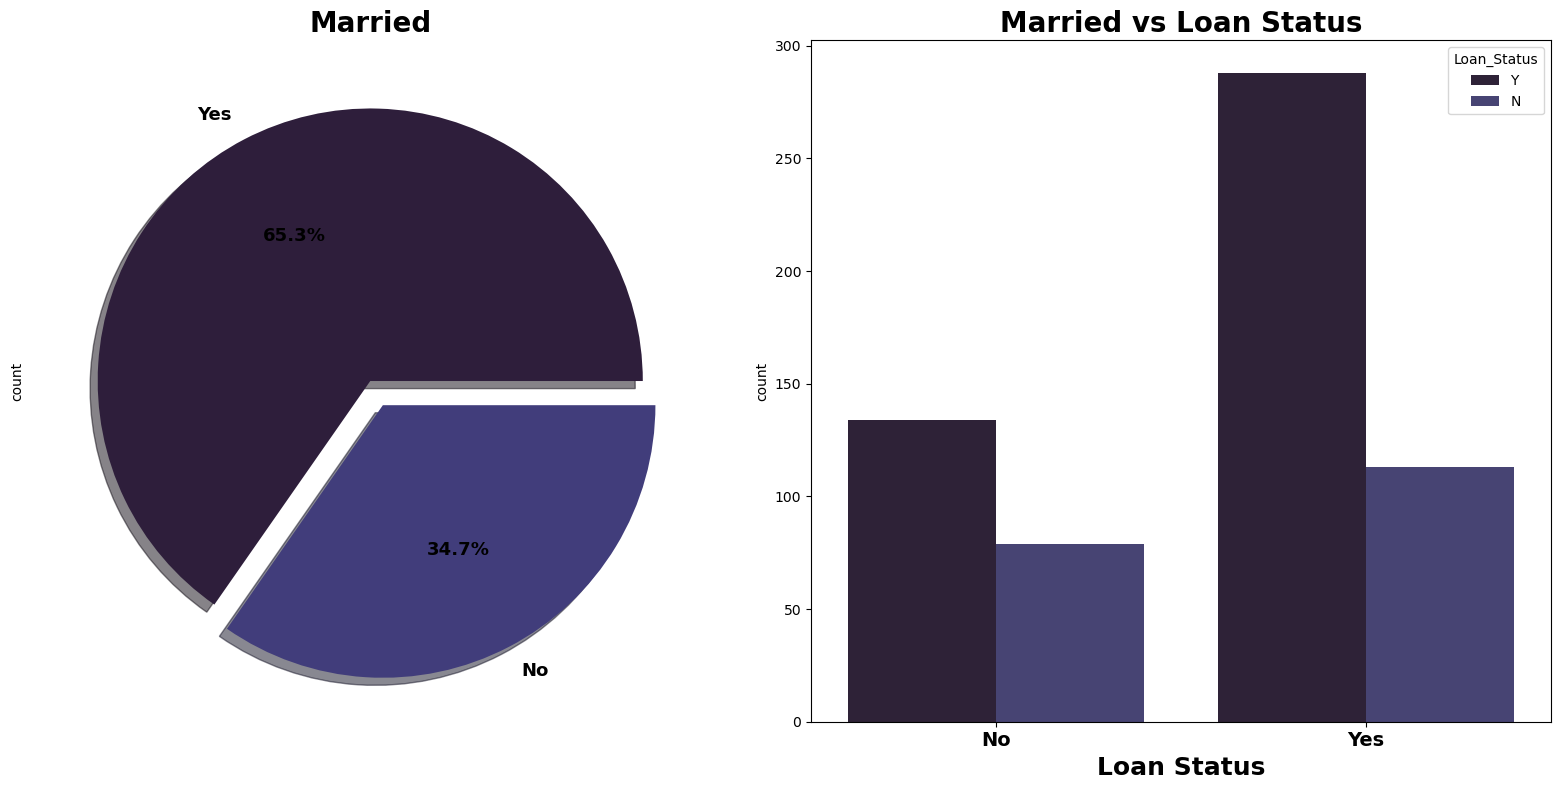

In [53]:
sns.set_palette("mako")
f,ax=plt.subplots(1,2,figsize=(16,8))
df.Married.value_counts().plot.pie(explode=[0,0.1],
                                       autopct='%2.1f%%',
                                      textprops={'fontweight':'bold',
                                                 'fontsize':13},
                                      ax=ax[0],
                                      shadow=True)
ax[0].set_title('Married',
                fontsize=20,
                fontweight='bold')
sns.countplot(x='Married',
              hue="Loan_Status",
             data=df,
             ax=ax[1])
ax[1].set_title('Married vs Loan Status',
                fontsize=20,
                fontweight='bold')
ax[1].set_xlabel('Loan Status',
                fontsize=18,
                fontweight='bold')
plt.xticks(fontsize=14,
          fontweight='bold')
plt.tight_layout()
plt.show()

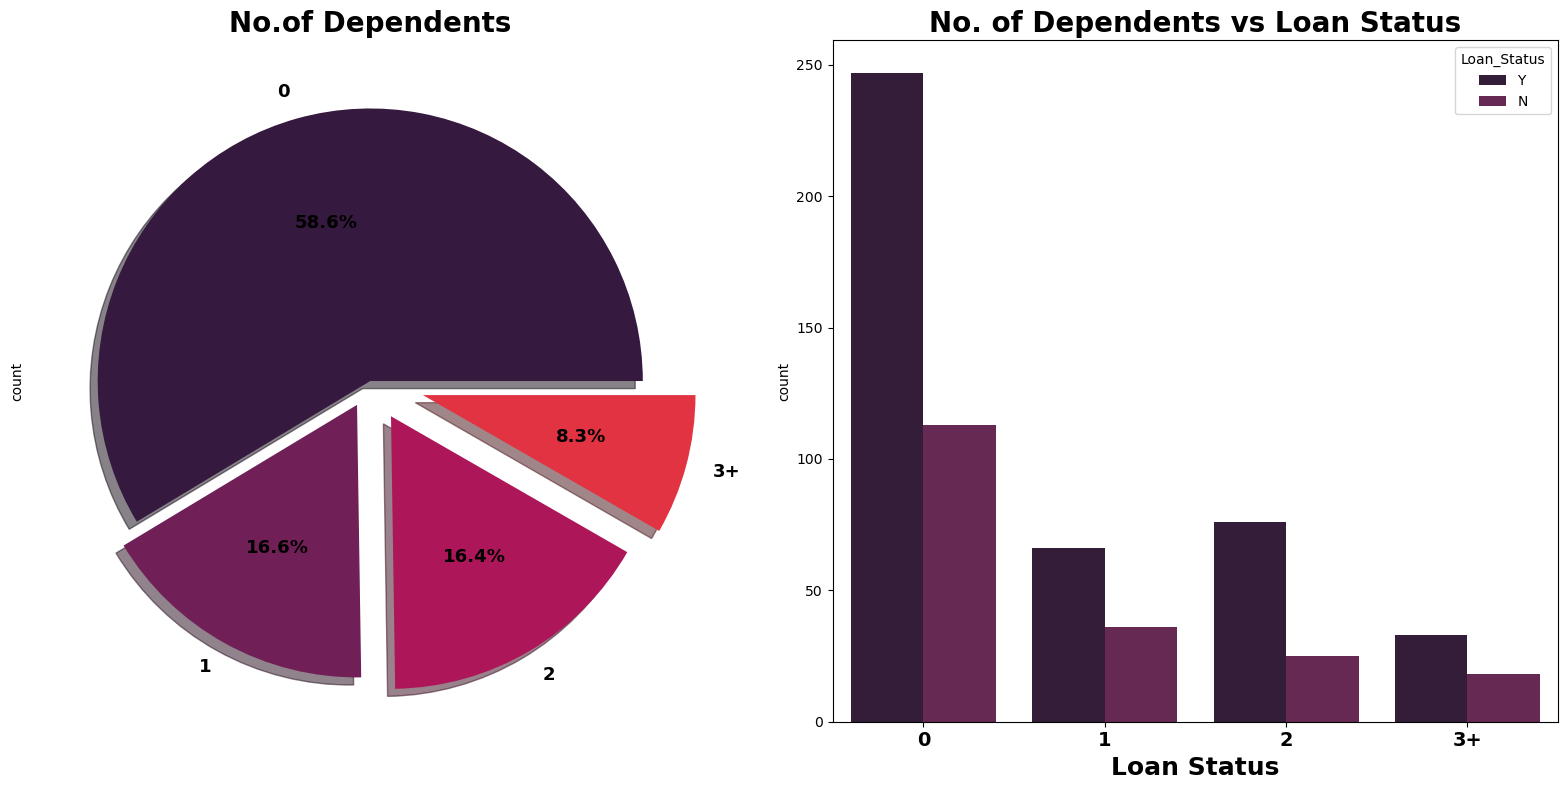

In [55]:
sns.set_palette("rocket")
f,ax=plt.subplots(1,2,figsize=(16,8))
df.Dependents.value_counts().plot.pie(explode=[0,0.1,0.15,0.2],
                                       autopct='%2.1f%%',
                                      textprops={'fontweight':'bold',
                                                 'fontsize':13},
                                      ax=ax[0],
                                      shadow=True)
ax[0].set_title('No.of Dependents',
                fontsize=20,
                fontweight='bold')
sns.countplot(x='Dependents',
              hue="Loan_Status",
             data=df,
             ax=ax[1])
ax[1].set_title('No. of Dependents vs Loan Status',
                fontsize=20,
                fontweight='bold')
ax[1].set_xlabel('Loan Status',
                fontsize=18,
                fontweight='bold')
plt.xticks(fontsize=14,
          fontweight='bold')
plt.tight_layout()
plt.show()

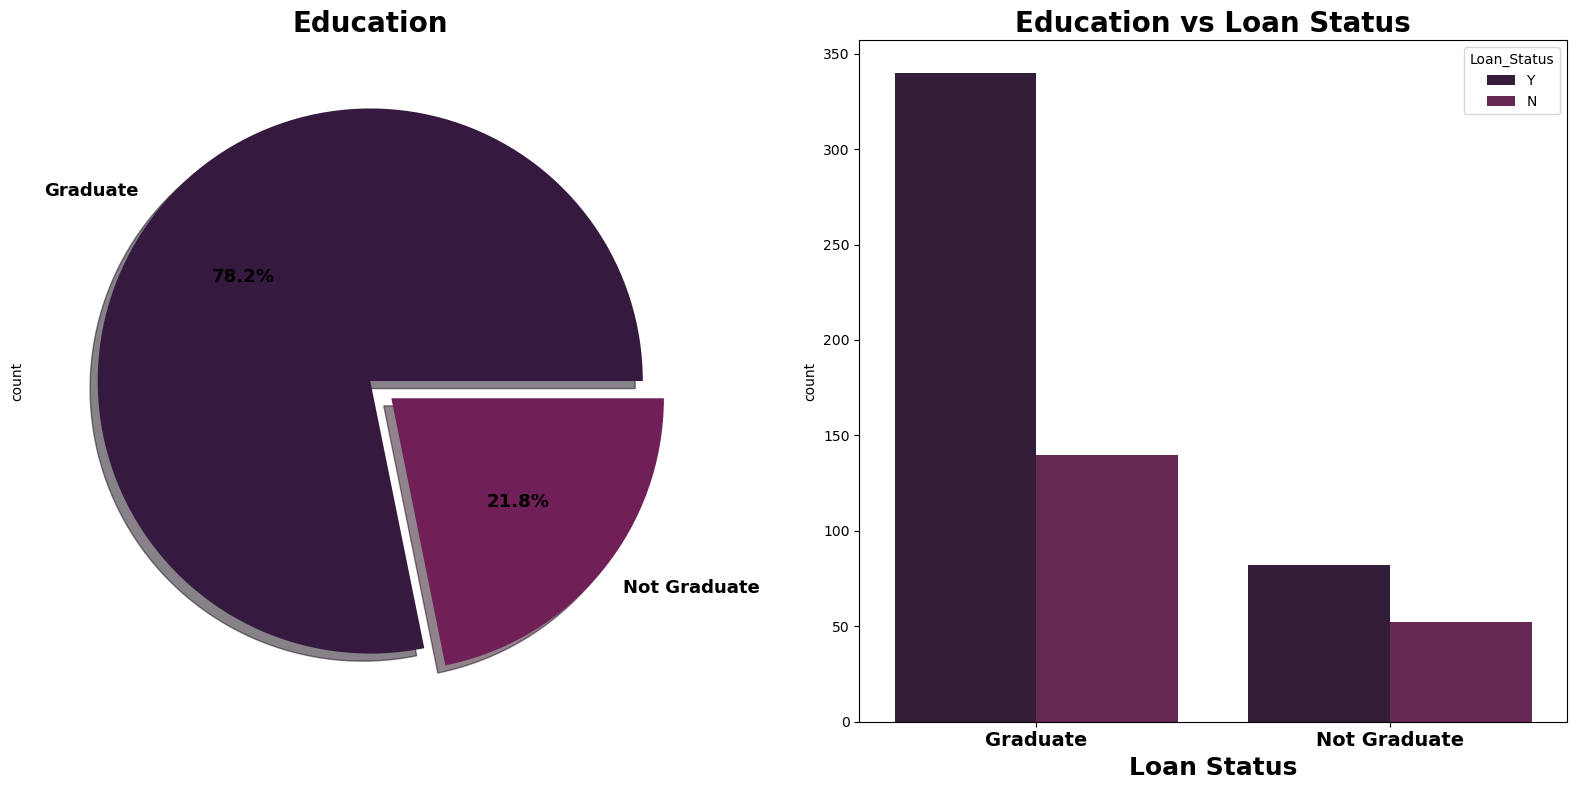

In [58]:
sns.set_palette("rocket")
f,ax=plt.subplots(1,2,figsize=(16,8))
df.Education.value_counts().plot.pie(explode=[0,0.1],
                                       autopct='%2.1f%%',
                                      textprops={'fontweight':'bold',
                                                 'fontsize':13},
                                      ax=ax[0],
                                      shadow=True)
ax[0].set_title('Education',
                fontsize=20,
                fontweight='bold')
sns.countplot(x='Education',
              hue="Loan_Status",
             data=df,
             ax=ax[1])
ax[1].set_title('Education vs Loan Status',
                fontsize=20,
                fontweight='bold')
ax[1].set_xlabel('Loan Status',
                fontsize=18,
                fontweight='bold')
plt.xticks(fontsize=14,
          fontweight='bold')
plt.tight_layout()
plt.show()

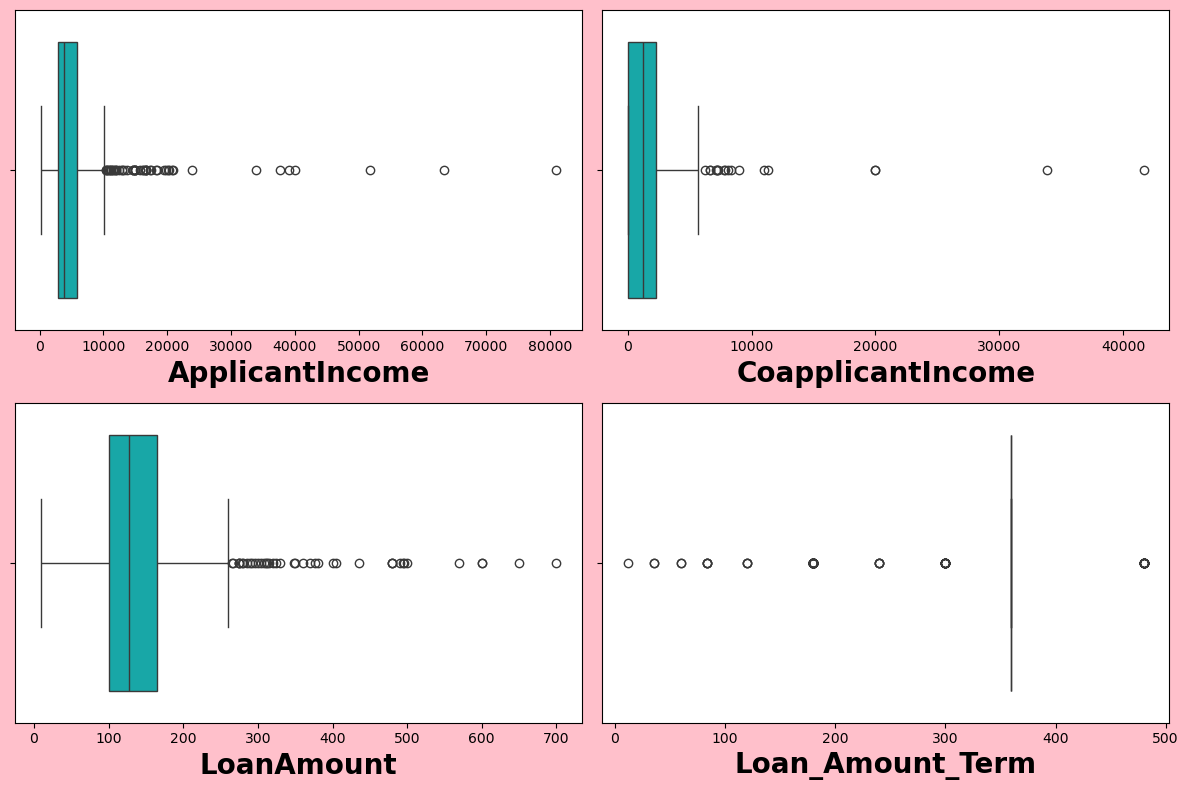

In [63]:
Numerical=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
sns.set_palette('rocket')
plt.figure(figsize=(12,8),facecolor='pink')
plotnumber=1
for i in Numerical:
    if plotnumber<=4:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(x=df[i],color='c')
        plt.xlabel(i,fontsize=20,fontweight='bold')
    plotnumber+=1
plt.tight_layout()
plt.show()